In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, accuracy_score

In [51]:
df = pd.read_csv("C:/Users/SOFT/Documents/Data sets/adult census income.csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [53]:
df.shape

(32561, 15)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


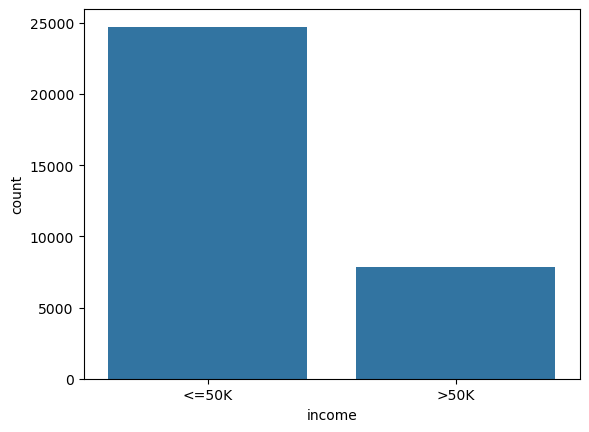

In [57]:
#check target distributions
sns.countplot(x='income', data=df)
plt.show()

In [59]:
#handle missing values
df = df.replace('?', np.nan)
df = df.dropna()

In [61]:
#encode target variable
le = LabelEncoder()
df['income'] = le.fit_transform(df['income'])

In [63]:
#identify numerical and categorical variables
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

In [65]:
# preprocessing pipeline for both numeric and categorical.

numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

In [67]:
#train test split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

#remove Target from Test Set,participants should NOT see test labels.
test_df = test_df.drop("income", axis=1)    

#add ID column
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)
train_df["id"] = train_df.index
test_df["id"] = test_df.index

#save to csv
train_df.to_csv("train.csv", index=False)
test_df.to_csv("test.csv", index=False)

#sample submission
sample = pd.DataFrame({
    "id": test_df["id"],
    "income": "<=50K"
})

sample.to_csv("sample_submission.csv", index=False)

In [69]:
#separate fetures and targets
X = train_df.drop("income", axis=1)
y = train_df["income"]

In [71]:
#take care of the id column
test_ids = test_df["id"]

X = X.drop("id", axis=1)
test_df = test_df.drop("id", axis=1)

In [73]:
X = pd.get_dummies(X)
test_df = pd.get_dummies(test_df)

In [75]:
#align the columns
X, test_df = X.align(test_df, join="left", axis=1, fill_value=0)

In [77]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [79]:
#baseline logistic regression pipeline
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

baseline_pred = model.predict(X_val)

baseline_accuracy = accuracy_score(y_val, baseline_pred)

print("Baseline Accuracy:", baseline_accuracy)
print(classification_report(y_val, baseline_pred))


Baseline Accuracy: 0.8489432242022379
              precision    recall  f1-score   support

           0       0.87      0.94      0.90      3627
           1       0.75      0.58      0.66      1199

    accuracy                           0.85      4826
   macro avg       0.81      0.76      0.78      4826
weighted avg       0.84      0.85      0.84      4826



C:\Users\SOFT\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [87]:
#hyperparameter tuning for logistic regression
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]  # supports both l1 & l2
}

model = LogisticRegression(max_iter=1000)

grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)

Best Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV AUC: 0.8487793975358743


In [93]:
#evaluate tuned model
best_model = grid.best_estimator_

y_pred_tuned = best_model.predict(X_val)
print("Tuned Accuracy:", accuracy_score(y_val, y_pred_tuned))
print(classification_report(y_val, y_pred_tuned))

Tuned Accuracy: 0.855781185246581
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      3627
           1       0.76      0.61      0.68      1199

    accuracy                           0.86      4826
   macro avg       0.82      0.77      0.79      4826
weighted avg       0.85      0.86      0.85      4826



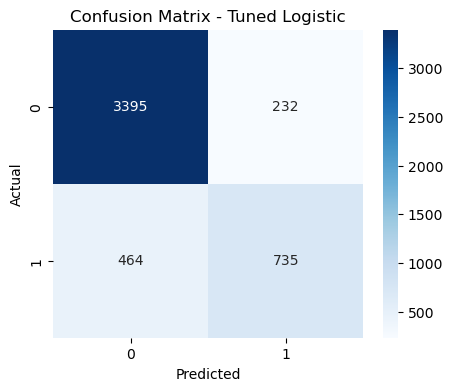

In [95]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred_tuned)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Logistic")
plt.show()